In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    precision_score, roc_auc_score
)

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=43
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_scaled, y_train)

print(classifier.predict(X_train_scaled)[:10])
print(classifier.predict(X_test_scaled)[:10])


[1 0 1 1 1 0 0 1 1 0]
[1 1 0 0 0 1 1 1 0 0]


In [ ]:
y_train_pred = classifier.predict(X_train_scaled)
y_train_proba = classifier.predict_proba(X_train_scaled)[:, 1]

print("F1 on the train set: ", f1_score(y_train, y_train_pred))
print("Accuracy on the train set: ", accuracy_score(y_train, y_train_pred))
print("Recall on the train set: ", recall_score(y_train, y_train_pred))
print("Precision on the train set: ", precision_score(y_train, y_train_pred))
print("ROC_AUC on the train set: ", roc_auc_score(y_train, y_train_proba))

print("\n")

y_test_pred = classifier.predict(X_test_scaled)
y_test_proba = classifier.predict_proba(X_test_scaled)[:, 1]

print("F1 on the test set: ", f1_score(y_test, y_test_pred))
print("Accuracy on the test set: ", accuracy_score(y_test, y_test_pred))
print("Recall on the test set: ", recall_score(y_test, y_test_pred))
print("Precision on the test set: ", precision_score(y_test, y_test_pred))
print("ROC_AUC on the test set: ", roc_auc_score(y_test, y_test_proba))

F1 on the train set:  0.9911504424778761
Accuracy on the train set:  0.989010989010989
Recall on the train set:  0.9929078014184397
Precision on the train set:  0.9893992932862191
ROC_AUC on the train set:  0.998995613495675


F1 on the test set:  0.9801324503311258
Accuracy on the test set:  0.9736842105263158
Recall on the test set:  0.9866666666666667
Precision on the test set:  0.9736842105263158
ROC_AUC on the test set:  0.9863247863247864


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, classifier.predict(X_test_scaled))
cm

array([[37,  2],
       [ 1, 74]])

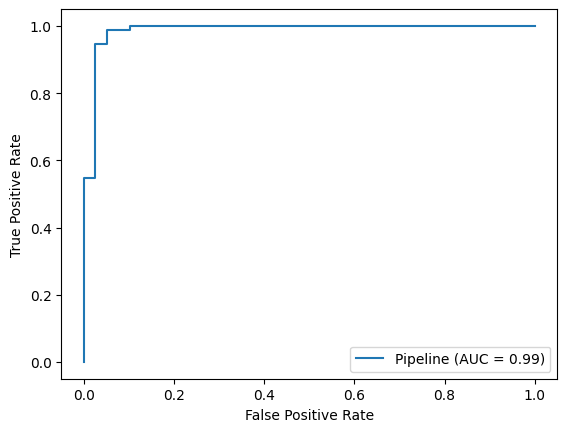

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_test_proba = classifier.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Pipeline (AUC = {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
